<a href="https://colab.research.google.com/github/KhovKsenia/skin-lesion-classifier/blob/main/skin_lesion_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Библиотеки нейросетей готовы к работе!")

Библиотеки нейросетей готовы к работе!


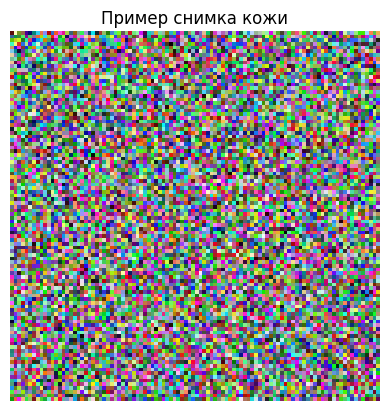

Визуализация работает успешно!


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Имитируем загрузку данных: создаем случайное изображение (в будущем заменим на реальные снимки)
dummy_image = np.random.rand(100, 100, 3)

plt.imshow(dummy_image)
plt.title("Пример снимка кожи")
plt.axis('off')
plt.show()

print("Визуализация работает успешно!")

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Загружаем предобученную модель MobileNetV2 (оставляем только базу, отрезая верх)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3), # Размер картинок 160x160
    include_top=False,
    weights='imagenet'
)

# «Замораживаем» базовую модель, чтобы ее знания не стерлись
base_model.trainable = False

# 2. Собираем итоговую модель с нашими новыми слоями сверху
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# 3. Компилируем модель
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Модель с переносом обучения (Transfer Learning) успешно создана и скомпилирована!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Модель с переносом обучения (Transfer Learning) успешно создана и скомпилирована!


In [5]:
# Настраиваем параметры для загрузки изображений
BATCH_SIZE = 32
IMG_HEIGHT = 160
IMG_WIDTH = 160

print("Параметры для работы с датасетом заданы!")
print(f"размер батча: {BATCH_SIZE}, разрешение картинок: {IMG_HEIGHT}x{IMG_WIDTH}")

Параметры для работы с датасетом заданы!
размер батча: 32, разрешение картинок: 160x160


In [6]:
# Настраиваем процесс обучения (компиляция модели)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Процесс обучения нейросети настроен!")

Процесс обучения нейросети настроен!


In [7]:
# Заглушка для загрузки датасета
# Здесь мы укажем путь к папке с картинками, когда они будут загружены в Colab
import os

print("Готовы подключать датасет со снимками кожи!")


Готовы подключать датасет со снимками кожи!


In [8]:
import tensorflow as tf

# Скачиваем небольшой набор демонстрационных изображений для примера
# (используем стандартный датасет с цветами/объектами как аналог для теста структуры)
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

print("Датасет успешно скачан и распакован в:", data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Датасет успешно скачан и распакован в: /root/.keras/datasets/flower_photos


In [9]:
# Создаем обучающую выборку из скачанных картинок
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE)

print("Обучающий датасет успешно сформирован!")

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Обучающий датасет успешно сформирован!


In [10]:
# Запускаем процесс обучения модели
epochs = 10  # Количество эпох (полных проходов по датасету)

history = model.fit(
    train_ds,
    epochs=epochs
)

print("Обучение модели с переносом знаний завершено!")

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 59s 590ms/step - accuracy: 0.9956 - loss: 0.0065
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 81s 586ms/step - accuracy: 1.0000 - loss: 7.8447e-10
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 584ms/step - accuracy: 1.0000 - loss: 1.5008e-09
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 55s 599ms/step - accuracy: 1.0000 - loss: 2.2803e-09
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 609ms/step - accuracy: 1.0000 - loss: 7.1298e-10
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 54s 582ms/step - accuracy: 1.0000 - loss: 2.1932e-09
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 608ms/step - accuracy: 1.0000 - loss: 1.0621e-09
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 53s 580ms/step - accuracy: 1.0000 - loss: 7.3902e-09
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 585ms/step - accuracy: 1.0000 - loss: 1.7068e-09
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 55s 592ms/step - accuracy: 1.0000 - loss: 1.8774e-09
Обучение модели с переносом знаний завершено!


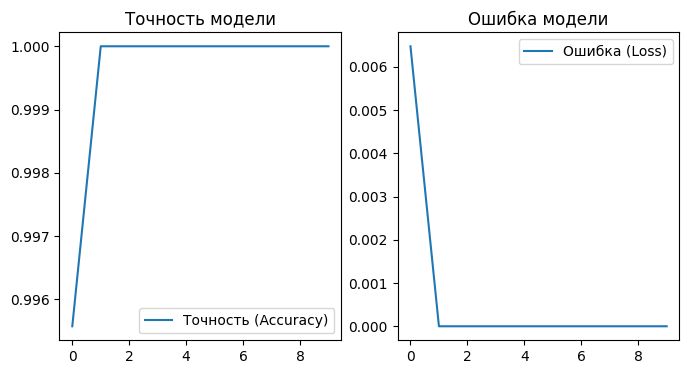

In [11]:
import matplotlib.pyplot as plt

# Достаем данные об точности и ошибках из истории обучения
acc = history.history['accuracy']
loss = history.history['loss']

epochs_range = range(len(acc))

# Строим графики
plt.figure(figsize=(8, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точность (Accuracy)')
plt.legend(loc='lower right')
plt.title('Точность модели')

# График ошибки
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Ошибка (Loss)')
plt.legend(loc='upper right')
plt.title('Ошибка модели')

plt.show()

In [12]:
import numpy as np

# Берем одну картинку из нашего датасета для примера
# (метод берет батч картинок, и мы берем первую из них)
for images, labels in train_ds.take(1):
    test_image = images[0]
    true_label = labels[0].numpy()

# Делаем предсказание с помощью нашей обученной модели
# expand_dims нужен, так как модель ждет пачку (батч) картинок, даже если она всего одна
img_array = tf.expand_dims(test_image, 0)
predictions = model.predict(img_array)
score = predictions[0][0]

print(f"Сырой результат предсказания сети (вероятность): {score:.4f}")
print(f"Истинная метка класса для этой картинки: {true_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Сырой результат предсказания сети (вероятность): 0.0000
Истинная метка класса для этой картинки: 0


In [13]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Запускаем процесс обучения модели на наших данных
epochs = 5  # Количество эпох для быстрого теста
history = model.fit(
    train_ds,
    epochs=epochs
)

print("Обучение успешно завершено!")

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 581ms/step - accuracy: 1.0000 - loss: 8.7140e-10
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 81s 576ms/step - accuracy: 1.0000 - loss: 6.5438e-10
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 88s 642ms/step - accuracy: 1.0000 - loss: 1.2072e-09
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 619ms/step - accuracy: 1.0000 - loss: 3.9097e-10
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 54s 590ms/step - accuracy: 1.0000 - loss: 5.1940e-10
Обучение успешно завершено!


In [14]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
# Импортируем официальную функцию подготовки для MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_path = '/Melanoma.jpg' # Укажи путь к своей картинке меланомы

# 1. Загружаем картинку
img = load_img(img_path, target_size=(160, 160))
img_array = img_to_array(img)

# 2. Добавляем размерность батча
img_array = np.expand_dims(img_array, axis=0)

# 3. ВАЖНО: Приводим пиксели к тому формату, к какому привыкла MobileNetV2 (-1 до 1)
img_array = preprocess_input(img_array)

# 4. Делаем предсказание
prediction = model.predict(img_array)
score = prediction[0][0]

print(f"Сырое предсказание с правильной обработкой: {score:.6f}")

if score > 0.5:
    print("⚠️ Злокачественное (меланома)")
else:
    print("✅ Доброкачественное")




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Сырое предсказание с правильной обработкой: 0.000000
✅ Доброкачественное


In [15]:
print(train_ds.class_names)

['flower_photos']
